<a href="https://colab.research.google.com/github/shashankmishra7-max/UIDAI_PROJECT/blob/main/Demographic_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
csv_files = [
    '/content/api_data_aadhar_demographic_0_500000.csv',
    '/content/api_data_aadhar_demographic_1000000_1500000.csv',
    '/content/api_data_aadhar_demographic_1500000_2000000.csv',
    '//content/api_data_aadhar_demographic_2000000_2071700.csv',
    '/content/api_data_aadhar_demographic_500000_1000000.csv'
]
df_list = []
for file in csv_files:
    if os.path.exists(file):
        df_list.append(pd.read_csv(file))
    else:
        print(f"Warning: File not found - {file}")
df = pd.concat(df_list, ignore_index=True)

print(f"Combined DataFrame shape: {df.shape}")
display(df.head())
display(df.info())

Combined DataFrame shape: (2071700, 6)


,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,01-03-2025,Uttar Pradesh,Gorakhpur,273213,49,529
1,01-03-2025,Andhra Pradesh,Chittoor,517132,22,375
2,01-03-2025,Gujarat,Rajkot,360006,65,765
3,01-03-2025,Andhra Pradesh,Srikakulam,532484,24,314
4,01-03-2025,Rajasthan,Udaipur,313801,45,785


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071700 entries, 0 to 2071699
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   date           object
 1   state          object
 2   district       object
 3   pincode        int64 
 4   demo_age_5_17  int64 
 5   demo_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 94.8+ MB


None

In [ ]:
df

,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,01-03-2025,Uttar Pradesh,Gorakhpur,273213,49,529
1,01-03-2025,Andhra Pradesh,Chittoor,517132,22,375
2,01-03-2025,Gujarat,Rajkot,360006,65,765
3,01-03-2025,Andhra Pradesh,Srikakulam,532484,24,314
4,01-03-2025,Rajasthan,Udaipur,313801,45,785
...,...,...,...,...,...,...
2071695,31-10-2025,Uttar Pradesh,Etah,207250,2,17
2071696,31-10-2025,Uttar Pradesh,Etah,207401,1,27
2071697,31-10-2025,Uttar Pradesh,Etawah,206003,3,10
2071698,31-10-2025,Uttar Pradesh,Etawah,206125,1,25


In [ ]:
initial_rows = df.shape[0]
print(f"Initial number of rows: {initial_rows}")

df_cleaned = df.drop_duplicates()

duplicate_rows_removed = initial_rows - df_cleaned.shape[0]
print(f"Number of duplicate rows removed: {duplicate_rows_removed}")

df = df_cleaned.copy() # Update the original DataFrame with the cleaned version

print(f"\nCleaned DataFrame shape: {df.shape}")
display(df.head())
display(df.info())

Initial number of rows: 2071700
Number of duplicate rows removed: 473601

Cleaned DataFrame shape: (1598099, 6)


,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,01-03-2025,Uttar Pradesh,Gorakhpur,273213,49,529
1,01-03-2025,Andhra Pradesh,Chittoor,517132,22,375
2,01-03-2025,Gujarat,Rajkot,360006,65,765
3,01-03-2025,Andhra Pradesh,Srikakulam,532484,24,314
4,01-03-2025,Rajasthan,Udaipur,313801,45,785


<class 'pandas.core.frame.DataFrame'>
Index: 1598099 entries, 0 to 2061699
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   date           1598099 non-null  object
 1   state          1598099 non-null  object
 2   district       1598099 non-null  object
 3   pincode        1598099 non-null  int64 
 4   demo_age_5_17  1598099 non-null  int64 
 5   demo_age_17_   1598099 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 85.3+ MB


None

In [ ]:
print("Unique values in 'state' column:")
print(df['state'].nunique())

print("\nUnique values in 'district' column:")
print(df['district'].nunique())

Unique values in 'state' column:
65

Unique values in 'district' column:
983


In [ ]:
print("All unique state names:")
print(df['state'].unique())

All unique state names:
['Uttar Pradesh' 'Andhra Pradesh' 'Gujarat' 'Rajasthan' 'Karnataka'
 'West Bengal' 'Telangana' 'Odisha' 'Maharashtra' 'Kerala' 'Bihar'
 'Tamil Nadu' 'Madhya Pradesh' 'Assam' 'Tripura' 'Arunachal Pradesh'
 'Punjab' 'Jharkhand' 'Delhi' 'Chandigarh' 'Chhattisgarh'
 'Jammu and Kashmir' 'Mizoram' 'Nagaland' 'Himachal Pradesh' 'Goa'
 'Haryana' 'Meghalaya' 'Uttarakhand' 'Manipur' 'Daman and Diu'
 'Puducherry' 'Sikkim' 'Ladakh' 'Dadra and Nagar Haveli and Daman and Diu'
 'Dadra and Nagar Haveli' 'Orissa' 'Pondicherry'
 'Andaman & Nicobar Islands' 'Andaman and Nicobar Islands' 'west Bengal'
 'Daman & Diu' 'West  Bengal' 'odisha' 'Jammu & Kashmir' 'Lakshadweep'
 'Dadra & Nagar Haveli' 'Westbengal' 'andhra pradesh' 'WEST BENGAL'
 'West Bangal' 'West bengal' 'ODISHA' 'WESTBENGAL' 'Chhatisgarh'
 'West Bengli' 'Darbhanga' 'Puttenahalli' 'Uttaranchal' 'BALANAGAR'
 'Jaipur' 'Madanapalle' '100000' 'Nagpur' 'Raja Annamalai Puram']


In [ ]:
df['state'] = df['state'].str.strip().str.title()

state_mapping = {
    'West Bangal': 'West Bengal',
    'West Bengli': 'West Bengal',
    'Westbengal': 'West Bengal',
    'West  Bengal': 'West Bengal',
    'Odisha': 'Odisha',
    'Odisha': 'Odisha',
    'Orissa': 'Odisha',
    'Pondicherry': 'Puducherry',
    'Uttaranchal': 'Uttarakhand',
    'Jammu & Kashmir': 'Jammu and Kashmir',
    'Daman & Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Daman and Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra and Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Andaman & Nicobar Islands': 'Andaman and Nicobar Islands'
}

df['state'] = df['state'].replace(state_mapping)

official_names = [
    'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Goa',
    'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jharkhand', 'Karnataka', 'Kerala',
    'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',
    'Odisha', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
    'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Andaman and Nicobar Islands',
    'Chandigarh', 'Dadra and Nagar Haveli and Daman and Diu', 'Lakshadweep',
    'Delhi', 'Puducherry', 'Ladakh', 'Jammu and Kashmir'
]

df = df[df['state'].isin(official_names)]

print(f"New unique state count: {df['state'].nunique()}")
print(df['state'].unique())

New unique state count: 36
['Uttar Pradesh' 'Andhra Pradesh' 'Gujarat' 'Rajasthan' 'Karnataka'
 'West Bengal' 'Telangana' 'Odisha' 'Maharashtra' 'Kerala' 'Bihar'
 'Tamil Nadu' 'Madhya Pradesh' 'Assam' 'Tripura' 'Arunachal Pradesh'
 'Punjab' 'Jharkhand' 'Delhi' 'Chandigarh' 'Chhattisgarh' 'Mizoram'
 'Nagaland' 'Himachal Pradesh' 'Goa' 'Haryana' 'Meghalaya' 'Uttarakhand'
 'Manipur' 'Puducherry' 'Sikkim' 'Ladakh' 'Andaman and Nicobar Islands'
 'Dadra and Nagar Haveli and Daman and Diu' 'Jammu and Kashmir'
 'Lakshadweep']


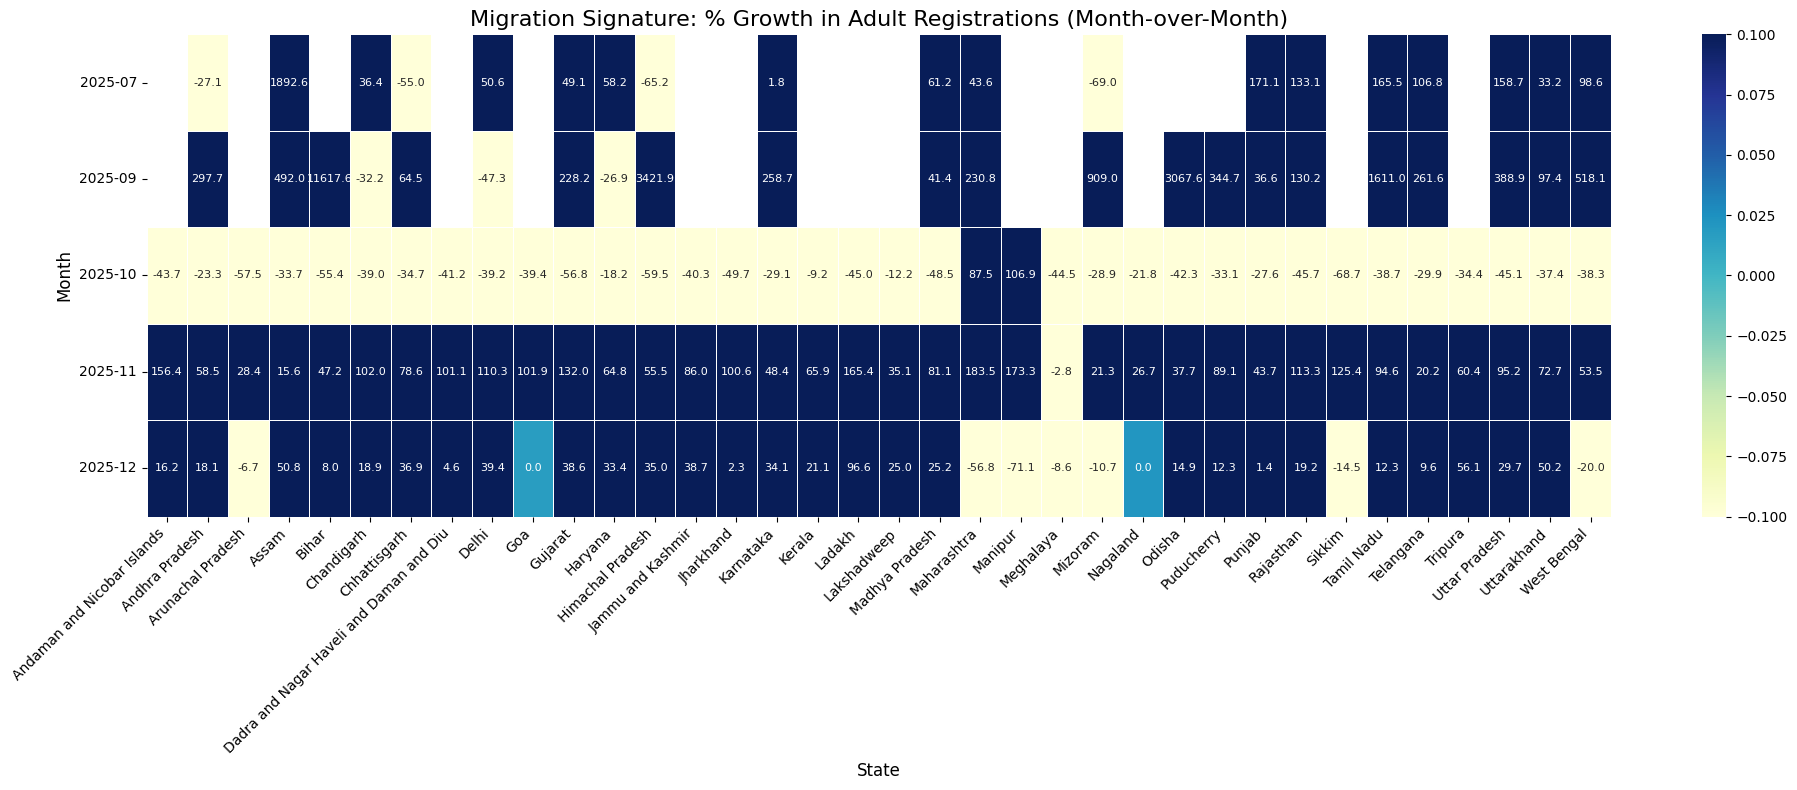

In [ ]:
sns.heatmap(
    migration_growth.tail(5),
    annot=True,
    cmap="YlGnBu",
    fmt=".1f",
    annot_kws={"size": 8},
    linewidths=0.5
)

plt.title("Migration Signature: % Growth in Adult Registrations (Month-over-Month)", fontsize=16)
plt.xlabel("State", fontsize=12)
plt.ylabel("Month", fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
df['total_registrations'] = df['demo_age_5_17'] + df['demo_age_17_']
df['youth_ratio'] = df['demo_age_5_17'] / df['total_registrations']

education_priority = df.groupby(['state', 'district', 'pincode'])['youth_ratio'].mean().reset_index()
education_priority = education_priority.sort_values(by='youth_ratio', ascending=False)

print("Top 5 Pincodes requiring Education Infrastructure (High Youth Ratio):")
display(education_priority.head(5))

Top 5 Pincodes requiring Education Infrastructure (High Youth Ratio):


,state,district,pincode,youth_ratio
8387,Himachal Pradesh,Lahaul and Spiti,172111,1.0
8390,Himachal Pradesh,Lahaul and Spiti,172117,1.0
20120,Rajasthan,Jodhpur,342021,1.0
73,Andhra Pradesh,Alluri Sitharama Raju,531027,1.0
20404,Rajasthan,Salumbar,313802,1.0


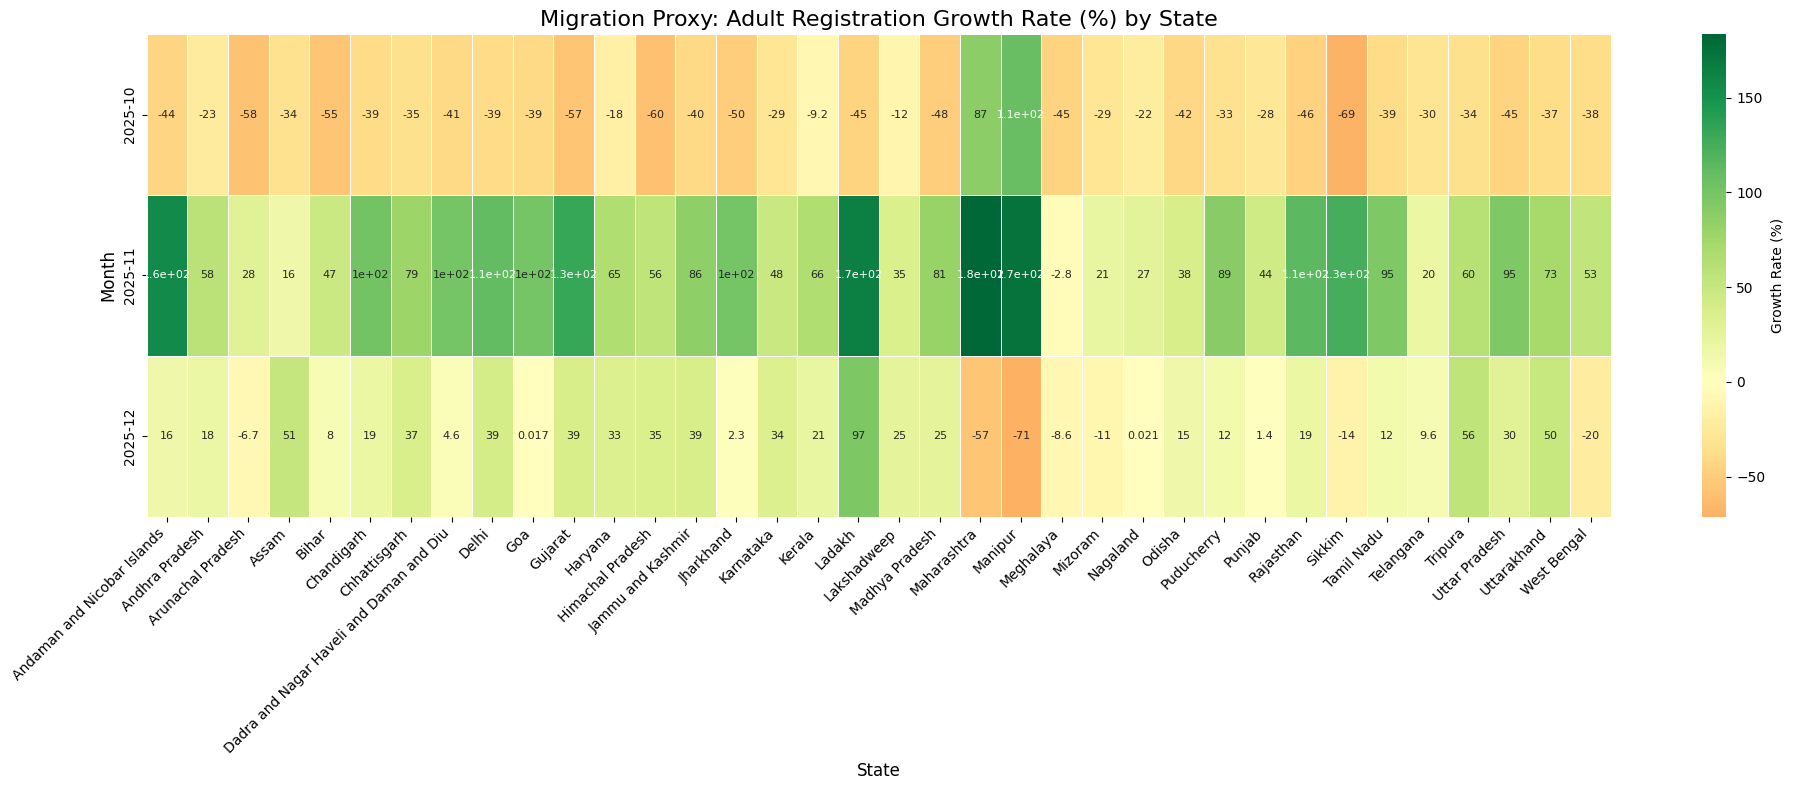

In [ ]:
plt.figure(figsize=(20, 8))
sns.heatmap(
    growth_rate.iloc[-3:],
    annot=True,
    cmap='RdYlGn',
    center=0,
    annot_kws={"size": 8},
    linewidths=0.5,
    cbar_kws={'label': 'Growth Rate (%)'}
)

plt.title("Migration Proxy: Adult Registration Growth Rate (%) by State", fontsize=16)
plt.ylabel("Month", fontsize=12)
plt.xlabel("State", fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
district_volume = df.groupby(['state', 'district'])['total_registrations'].sum().reset_index()

underserved_districts = district_volume.sort_values(by='total_registrations').head(10)

print("Districts with Lowest Registration Volume (Service Gaps):")
display(underserved_districts)

Districts with Lowest Registration Volume (Service Gaps):


,state,district,total_registrations
493,Maharashtra,Dist : Thane,1
393,Karnataka,Udupi *,1
840,Uttar Pradesh,Chandauli *,1
863,Uttar Pradesh,Jyotiba Phule Nagar *,1
921,West Bengal,Bally Jagachha,1
930,West Bengal,Domjur,1
593,Odisha,Balianta,1
597,Odisha,Bhadrak(R),1
307,Jammu and Kashmir,Pulwama,1
842,Uttar Pradesh,Chitrakoot *,1


In [ ]:
pincode_stats = df.groupby('pincode')['total_registrations'].agg(['mean', 'std']).reset_index()

anomaly_df = df.merge(pincode_stats, on='pincode')

anomaly_df['is_anomaly'] = anomaly_df['total_registrations'] > (anomaly_df['mean'] + 3 * anomaly_df['std'])

anomalies_found = anomaly_df[anomaly_df['is_anomaly'] == True]

print(f"Detected {len(anomalies_found)} statistical anomalies for investigation.")
display(anomalies_found[['date', 'state', 'district', 'pincode', 'total_registrations']].head())

Detected 21591 statistical anomalies for investigation.


,date,state,district,pincode,total_registrations
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,578
1,2025-03-01,Andhra Pradesh,Chittoor,517132,397
2,2025-03-01,Gujarat,Rajkot,360006,830
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,338
4,2025-03-01,Rajasthan,Udaipur,313801,830
